#### **Assignment 3: Regularization and Distances**

**Members: Cui(Cathy) Yu, Shravani Mahadeshwar, Priya Botsa, Marc Hayes, Shaonan Feng and Di Yang**

- *Course: Machine Learning 2*
- *Prof: Jan Nagler*
- *Due: 25 April 2026*

**Methodology**

**Part 1: Clustering**

**Dataset**
- The Human Activity Recognition dataset, with 561 engineered features
- Chosen because
    1) the number of features allows a implementation of regularization
    2) many features represent different transformations of the same underlying signals, leading to strong redundancy and correlation

**Regularization methods**
- Ridge: retains all features while shrinking their coeeficients, leading to more stable models
- Lasso: reduces number of active features, effective feature selection
- ElasticNet: compromise, preserves groups of features while still reducing sparsity 



#### **1. Regularization Study**

**Importing necessary libraries**

In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import ElasticNetCV
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder

**Loading the dataset**

In [2]:
# Load HAR dataset
har = fetch_openml(name="HAR", version=1, as_frame=True)

df = har.frame

# Separate features and target
X = df.drop(columns=["Class"])
y = df["Class"]

print(X.shape)  
print(y.value_counts())

(10299, 561)
Class
6    1944
5    1906
4    1777
1    1722
2    1544
3    1406
Name: count, dtype: int64


**EDA**

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10299 entries, 0 to 10298
Columns: 561 entries, V1 to V561
dtypes: float64(561)
memory usage: 44.1 MB
None
      count      mean       std  min       25%       50%       75%  max
V1  10299.0  0.274347  0.067628 -1.0  0.262624  0.277174  0.288354  1.0
V2  10299.0 -0.017743  0.037128 -1.0 -0.024903 -0.017162 -0.010625  1.0
V3  10299.0 -0.108925  0.053033 -1.0 -0.121019 -0.108596 -0.097589  1.0
V4  10299.0 -0.607784  0.438694 -1.0 -0.992360 -0.943030 -0.250293  1.0
V5  10299.0 -0.510191  0.500240 -1.0 -0.976990 -0.835032 -0.057336  1.0
0


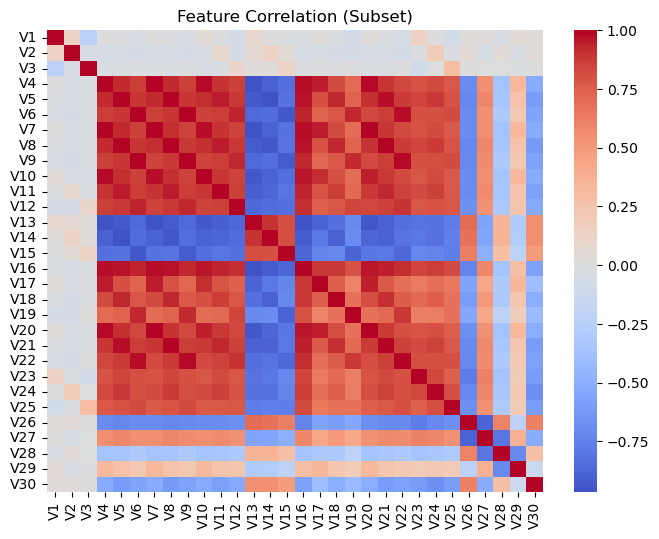

In [3]:
# Basic info
print(X.info())
print(X.describe().T.head())

# Check missing values
print(X.isnull().sum().sum())

# Correlation (subset to avoid huge plot)

subset = X.iloc[:, :30]  # first 30 features
plt.figure(figsize=(8, 6))
sns.heatmap(subset.corr(), cmap="coolwarm", center=0)
plt.title("Feature Correlation (Subset)")
plt.show()

**Pre-processing**

In [4]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scaling with StandardScaler (mean=0, std=1) 
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Define Models** 

In [5]:
# Ridge
def do_ridge(lambdaaa):
    ridge = Ridge(alpha=lambdaaa, max_iter=5000)
    
    ridge.fit(X_train, y_train)
    
    ridge_train_score = ridge.score(X_train, y_train)
    ridge_test_score = ridge.score(X_test, y_test)
    ridge_num_features = np.sum(ridge.coef_ != 0)
    ridge_coef = ridge.coef_
    
    return [round(lambdaaa, 4), round(ridge_train_score, 4), 
            round(ridge_test_score, 4), ridge_num_features], list(ridge_coef)

# LASSO
def do_lasso(lambdaaa):
    lasso = Lasso(alpha=lambdaaa, max_iter=5000)
    lasso.fit(X_train, y_train)
    
    lasso_train_score = lasso.score(X_train, y_train)
    lasso_test_score = lasso.score(X_test, y_test)
    lasso_num_features = np.sum(lasso.coef_ != 0)
    lasso_coef = lasso.coef_
    
    return [round(lambdaaa, 4), round(lasso_train_score, 4), 
            round(lasso_test_score, 4), lasso_num_features], list(lasso_coef)

# Elastic Net
def do_elastic(lambdaaa):
    elast = ElasticNet(alpha=lambdaaa, l1_ratio=0.5, max_iter=5000)
    elast.fit(X_train, y_train)
    
    elast_train_score = elast.score(X_train, y_train)
    elast_test_score = elast.score(X_test, y_test)
    elast_num_features = np.sum(elast.coef_ != 0)
    elast_coef = elast.coef_
    
    return [round(lambdaaa, 4), round(elast_train_score, 4), 
            round(elast_test_score, 4), elast_num_features], list(elast_coef)

**Ridge (L2)** 

In [6]:
results, coefficient = [], []

for i in np.linspace(0.0001, 1, 30):
    run, coef_run = do_ridge(i)
    results.append(run)
    coefficient.append(coef_run)

temp_1 = pd.DataFrame(results, columns=["Lambda", "Train Score", "Test Score", "Number of features"])
temp_2 = pd.DataFrame(coefficient, columns=X.columns)

ridge_results = pd.concat([temp_1, temp_2], axis=1)
ridge_results.head()

,Lambda,Train Score,Test Score,Number of features,V1,V2,V3,V4,V5,V6,...,V552,V553,V554,V555,V556,V557,V558,V559,V560,V561
0,0.0001,0.9738,0.9712,561,-0.280656,0.315687,0.059701,1.439544,1.040430,3.435252,...,0.168923,-0.149007,0.080032,-0.010337,-0.016636,0.043395,0.012038,-2.058566,-1.472830,-1.330236
1,0.0346,0.9735,0.9711,561,-0.271168,0.327253,0.044531,0.836700,-0.115349,0.895241,...,0.168138,-0.182648,0.114514,-0.012088,-0.012955,0.042302,0.011134,-1.954734,-1.357441,-1.308644
2,0.0691,0.9734,0.9710,561,-0.269422,0.330770,0.036116,0.569230,-0.428844,0.415350,...,0.161054,-0.189526,0.123029,-0.011458,-0.011927,0.041825,0.011267,-1.884915,-1.302546,-1.277685
3,0.1035,0.9733,0.9709,561,-0.267048,0.333203,0.031195,0.457276,-0.558078,0.209966,...,0.153861,-0.192745,0.127828,-0.010558,-0.011312,0.041488,0.011414,-1.823655,-1.255879,-1.249447
4,0.1380,0.9732,0.9709,561,-0.264019,0.334541,0.027841,0.395876,-0.624891,0.095805,...,0.147177,-0.194478,0.131012,-0.009605,-0.010887,0.041228,0.011544,-1.768313,-1.214204,-1.223214


**Lasso (L1)**

In [7]:
results, coefficient = [], []

for i in np.linspace(0.0001, 1, 30):
    run, coef_run = do_lasso(i)
    results.append(run)
    coefficient.append(coef_run)

temp_1 = pd.DataFrame(results, columns=["Lambda", "Train Score", "Test Score", "Number of features"])
temp_2 = pd.DataFrame(coefficient, columns=X.columns)

lasso_results = pd.concat([temp_1, temp_2], axis=1)
lasso_results.head()

/Applications/anaconda3/envs/DataAnalytics/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.259e+02, tolerance: 2.505e+00
  model = cd_fast.enet_coordinate_descent(


,Lambda,Train Score,Test Score,Number of features,V1,V2,V3,V4,V5,V6,...,V552,V553,V554,V555,V556,V557,V558,V559,V560,V561
0,0.0001,0.9710,0.9691,337,-0.025061,0.119503,0.0,0.0,-2.477395,-0.238205,...,0.046205,-0.165284,0.129394,0.01492,-0.009352,0.040456,0.013995,-1.087261,-0.581612,-0.789304
1,0.0346,0.8723,0.8749,14,-0.000000,0.000000,0.0,0.0,-0.000000,-0.000000,...,-0.000000,-0.000000,-0.000000,-0.00000,-0.000000,0.000000,-0.000000,0.000000,-0.000000,-0.000000
2,0.0691,0.8347,0.8371,4,-0.000000,0.000000,0.0,0.0,-0.000000,-0.000000,...,-0.000000,-0.000000,-0.000000,-0.00000,-0.000000,0.000000,-0.000000,0.000000,-0.000000,-0.000000
3,0.1035,0.8252,0.8270,3,-0.000000,0.000000,0.0,-0.0,-0.000000,-0.000000,...,-0.000000,-0.000000,-0.000000,-0.00000,-0.000000,0.000000,-0.000000,0.000000,-0.000000,-0.000000
4,0.1380,0.8146,0.8158,3,0.000000,0.000000,0.0,-0.0,-0.000000,-0.000000,...,-0.000000,-0.000000,-0.000000,-0.00000,-0.000000,0.000000,-0.000000,0.000000,-0.000000,-0.000000


**Elastic Net**

In [8]:
results, coefficient = [], []

for i in np.linspace(0.0001, 1, 30):
    run, coef_run = do_elastic(i)
    results.append(run)
    coefficient.append(coef_run)

temp_1 = pd.DataFrame(results, columns=["Lambda", "Train Score", "Test Score", "Number of features"])
temp_2 = pd.DataFrame(coefficient, columns=X.columns)

elastic_results = pd.concat([temp_1, temp_2], axis=1)
elastic_results.head()

/Applications/anaconda3/envs/DataAnalytics/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.337e+02, tolerance: 2.505e+00
  model = cd_fast.enet_coordinate_descent(


,Lambda,Train Score,Test Score,Number of features,V1,V2,V3,V4,V5,V6,...,V552,V553,V554,V555,V556,V557,V558,V559,V560,V561
0,0.0001,0.9716,0.9694,411,-0.109102,0.20185,0.0,-0.0,-1.612763,-0.618667,...,0.077151,-0.183507,0.141379,0.006739,-0.007246,0.039777,0.013024,-1.129592,-0.691005,-0.846158
1,0.0346,0.9086,0.9098,51,0.000000,0.00000,0.0,0.0,-0.013507,-0.000000,...,-0.058270,0.000000,-0.000000,0.000000,0.000000,0.003385,0.000000,0.000000,0.000000,0.000000
2,0.0691,0.8587,0.8612,24,-0.000000,0.00000,0.0,0.0,-0.000000,-0.000000,...,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,0.000000,-0.000000,0.000000,-0.000000,-0.000000
3,0.1035,0.8313,0.8339,14,-0.000000,0.00000,0.0,0.0,-0.000000,-0.000000,...,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,0.000000,-0.000000,0.000000,-0.000000,-0.000000
4,0.1380,0.8235,0.8258,13,-0.000000,0.00000,0.0,-0.0,-0.000000,-0.000000,...,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,0.000000,-0.000000,0.000000,-0.000000,-0.000000


**Cross validation**

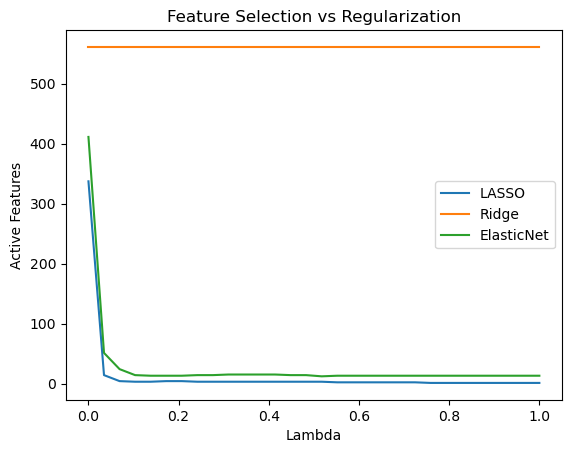

In [9]:
# number of features
plt.plot(lasso_results["Lambda"], lasso_results["Number of features"], label="LASSO")
plt.plot(ridge_results["Lambda"], ridge_results["Number of features"], label="Ridge")
plt.plot(elastic_results["Lambda"], elastic_results["Number of features"], label="ElasticNet")

plt.xlabel("Lambda")
plt.ylabel("Active Features")
plt.title("Feature Selection vs Regularization")
plt.legend()
plt.show()


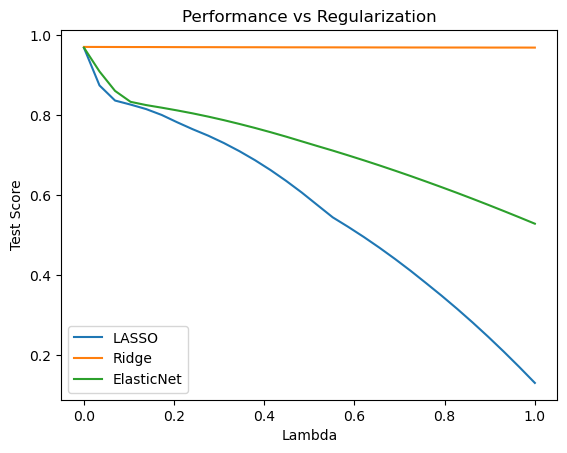

In [10]:
# train and test score
plt.plot(lasso_results["Lambda"], lasso_results["Test Score"], label="LASSO")
plt.plot(ridge_results["Lambda"], ridge_results["Test Score"], label="Ridge")
plt.plot(elastic_results["Lambda"], elastic_results["Test Score"], label="ElasticNet")

plt.xlabel("Lambda")
plt.ylabel("Test Score")
plt.title("Performance vs Regularization")
plt.legend()
plt.show()

**Conclusion**

#### **2. Distances and Clustering in DNA-Like Sequences**

**Importing necessary libraries**

In [1]:
import pandas as pd
import matplotlib.gridspec as gridspec
import numpy as np
from itertools import product
from scipy.spatial.distance import hamming, squareform
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.cluster import KMeans, DBSCAN, SpectralClustering      
import hdbscan  
from statistics import mean                                     
from sklearn.manifold import MDS, TSNE
import umap
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
np.random.seed(42)

**Loading the dataset**

In [2]:
data=pd.read_csv("./data/highly_classified_data.csv",sep=";")
data.head()

,ID,Sequence,Unnamed: 2
0,seq1,CAAACTTATTCGACGATTGACTTAATCTTAATGATATCGAAGGTTA...,NaN
1,seq2,CAAACTTATTAGACGATTGACTTAATCTTAGTGATATCGAAGGTAA...,NaN
2,seq3,CAAACTTATTCGACGATTGACTTAATCTTAGTGATATCGAAGGTAA...,NaN
3,seq4,CAAACTTATTCGACGATTGACTTAATCTTAGTGATATCGAAGGTAA...,NaN
4,seq5,CAAACTTATTCGACGATTGACTTAATCTTAGTGATATCGAAGGTAA...,NaN


In [3]:
print(data['Unnamed: 2'].value_counts())
# Dropping the 'Unnamed: 2' column as it contains NaN 
data = data.drop(columns=['Unnamed: 2'])
data.sample(4)

Series([], Name: count, dtype: int64)


,ID,Sequence
83,seq84,GGAGGATTGAGGTTCAGTATCACCAAGTGCCTGACCAGGTGGTTAA...
53,seq54,ATAGGAGGTTTCGCGAAGTGGGTGATAGCCGATGGTAGCCGGCCCA...
70,seq71,ATAGGAGGTTTCGCGGAGTGGGTGATATCAGATTGTAGCCGGCCCA...
45,seq46,TTGCCGGACGTTCCCAGAGCTCCGGATGTGAACTTCGTTCACTGAT...


**EDA**

In [4]:
# Checking for missing values
print("Missing values in each column:")
print(data.isnull().sum())
# Checking for duplicates
print("Number of duplicate rows:", data.duplicated().sum())
# Length of the sequences
print("Average length of the sequences:", mean(data['Sequence'].apply(len)))
# Unique characters in the sequences
unique_characters = set(''.join(data['Sequence'].tolist()))
print(f"Unique characters in the sequences: {sorted(unique_characters)}")

Missing values in each column:
ID          0
Sequence    0
dtype: int64
Number of duplicate rows: 0
Average length of the sequences: 10000
Unique characters in the sequences: ['A', 'C', 'G', 'T']


In [5]:
# Checking for malformed sequences (non-ACGT characters)
data["valid"] = data["Sequence"].apply(lambda s: set(s).issubset(set("ACGT")))
print(f"Malformed sequences: {(~data['valid']).sum()}")

Malformed sequences: 0


- No sequences are malformed as all of them contain only A, C, G, T nucleotides

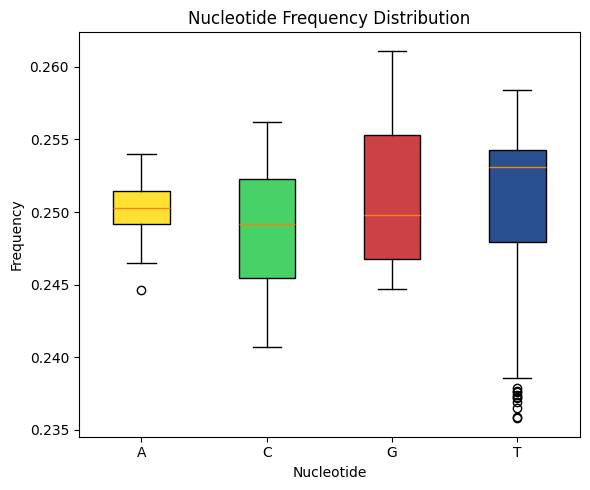

In [6]:
# Calculating frequency of each unique character in the sequences
for nuc in sorted(unique_characters):
    data[f"freq_{nuc}"] = data["Sequence"].apply(lambda s: s.count(nuc) / len(s))
fig, ax = plt.subplots(figsize=(6, 5))
freq_data = [data[f"freq_{n}"].values for n in sorted(unique_characters)]
bp = ax.boxplot(freq_data, labels=list(sorted(unique_characters)), patch_artist=True)
colors = ["#FFE134", "#47D167", "#CC4146", "#285091"]
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
ax.set_title("Nucleotide Frequency Distribution")
ax.set_ylabel("Frequency")
ax.set_xlabel("Nucleotide")
plt.tight_layout()
plt.show()

**Sequence representation**

In [7]:
def kmer_freq_vector(seq, k, kmer_list):
    """Computing k-mer frequency vector for a sequence."""
    total = len(seq) - k + 1
    counts = {km: 0 for km in kmer_list}
    for i in range(total):
        tri = seq[i:i+k]
        if tri in counts:
            counts[tri] += 1
    return np.array([counts[km] / total for km in kmer_list])
def normalized_hamming(s1, s2):
    """Computing normalized Hamming distance between two equal-length strings."""
    assert len(s1) == len(s2), "Sequences must be equal length for Hamming."
    return sum(c1 != c2 for c1, c2 in zip(s1, s2)) / len(s1)

In [8]:
# 1. Trinucleotide frequencies (k=3) (Euclidean distance)
k=3
seqs = data['Sequence'].tolist()
k_mers = [''.join(p) for p in product("ACGT", repeat=k)] #4^3=64 possible trinucleotides
kmer_matrix = np.array([kmer_freq_vector(s, k, k_mers) for s in seqs])
print(f"Trinucleotide frequency matrix shape: {kmer_matrix.shape}")

Trinucleotide frequency matrix shape: (100, 64)


In [9]:
# 2. Normalized Hamming distance matrix (Non-euclidean distance)
hamming_matrix = np.zeros((len(seqs), len(seqs)))
for i in range(len(seqs)):
    for j in range(i + 1, len(seqs)):
        d = normalized_hamming(seqs[i], seqs[j])
        hamming_matrix[i, j] = d
        hamming_matrix[j, i] = d
print(f"Hamming distance matrix shape: {hamming_matrix.shape}")
print(f"Mean pairwise distance: {hamming_matrix[hamming_matrix > 0].mean():.4f}")

Hamming distance matrix shape: (100, 100)
Mean pairwise distance: 0.5829


**Distance matrix**

**Clustering**

**Dimensionality reduction**

**Cluster validation**

**Within cluster sequence analysis**

**Metrics Conclusion**

**Conclusion**

**Take-away**

**1. Regularization**

- 
- 



**2. Distances**

- 
- 